# Olist 电商数据分析

数据加载与合并 -> 数据清洗 -> 探索性分析(EDA) -> RFM客户分层 -> 配送时效与满意度检验

## 阶段0-1: 读取数据并合并成两张主表

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

orders = pd.read_csv('../data/olist_orders_dataset.csv')
customers = pd.read_csv('../data/olist_customers_dataset.csv')
order_items = pd.read_csv('../data/olist_order_items_dataset.csv')
products = pd.read_csv('../data/olist_products_dataset.csv')
sellers = pd.read_csv('../data/olist_sellers_dataset.csv')
payments = pd.read_csv('../data/olist_order_payments_dataset.csv')
reviews = pd.read_csv('../data/olist_order_reviews_dataset.csv')
category_translation = pd.read_csv('../data/product_category_name_translation.csv')

# full: 商品级别主表(用于销售/品类/卖家分析)
full = orders.merge(customers, on='customer_id', how='left')
full = full.merge(order_items, on='order_id', how='left')
full = full.merge(products, on='product_id', how='left')
full = full.merge(sellers, on='seller_id', how='left')
full = full.merge(category_translation, on='product_category_name', how='left')
print("full:", full.shape)

full: (113425, 30)


In [2]:
# orders_summary: 订单级别主表(用于客户/支付/评价分析)
payments_summary = payments.groupby('order_id')['payment_value'].sum().reset_index()
orders_summary = orders.merge(customers, on='customer_id', how='left')
orders_summary = orders_summary.merge(reviews, on='order_id', how='left')
orders_summary = orders_summary.merge(payments_summary, on='order_id', how='left')
print("orders_summary:", orders_summary.shape)

orders_summary: (99992, 19)


## 阶段2: 数据清洗

In [3]:
date_cols = ['order_purchase_timestamp', 'order_approved_at',
             'order_delivered_carrier_date', 'order_delivered_customer_date',
             'order_estimated_delivery_date']
for col in date_cols:
    full[col] = pd.to_datetime(full[col])
    orders_summary[col] = pd.to_datetime(orders_summary[col])

full['delivery_days'] = (full['order_delivered_customer_date'] - full['order_purchase_timestamp']).dt.days
orders_summary['delivery_days'] = (orders_summary['order_delivered_customer_date'] - orders_summary['order_purchase_timestamp']).dt.days

full['product_category_name'] = full['product_category_name'].fillna('unknown')
full['product_category_name_english'] = full['product_category_name_english'].fillna('unknown')

print("清洗完成, 完全重复行数:", full.duplicated().sum())

清洗完成, 完全重复行数: 0


## 阶段3: 探索性分析(EDA)

### 3.1 月度销售趋势

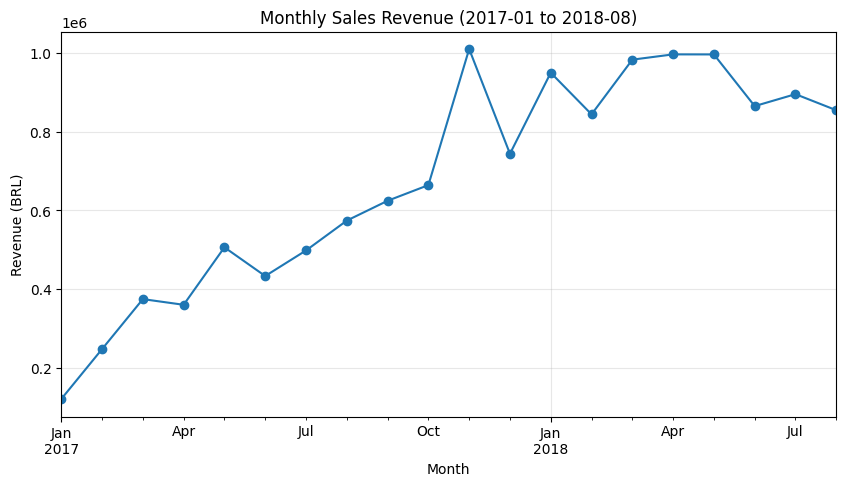

In [4]:
full['order_month'] = full['order_purchase_timestamp'].dt.to_period('M')
monthly_sales = full.groupby('order_month')['price'].sum()['2017-01':'2018-08']

plt.figure(figsize=(10, 5))
monthly_sales.plot(kind='line', marker='o')
plt.title('Monthly Sales Revenue (2017-01 to 2018-08)')
plt.xlabel('Month'); plt.ylabel('Revenue (BRL)'); plt.grid(alpha=0.3)
plt.show()

### 3.2 品类销售额 Top10

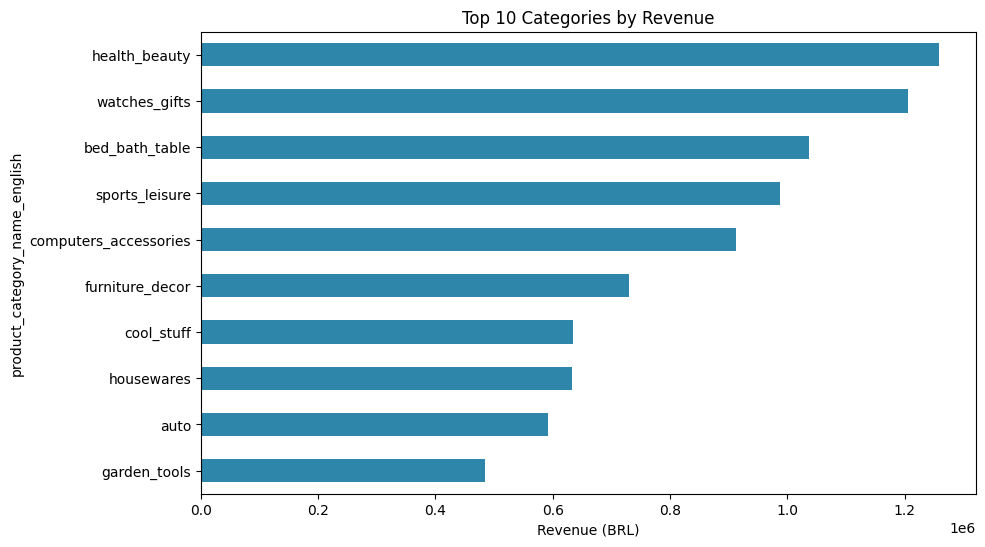

In [5]:
top_categories = full.groupby('product_category_name_english')['price'].sum().sort_values(ascending=False).head(10)
plt.figure(figsize=(10, 6))
top_categories.sort_values().plot(kind='barh', color='#2E86AB')
plt.title('Top 10 Categories by Revenue'); plt.xlabel('Revenue (BRL)')
plt.show()

### 3.3 各州销售额 Top10

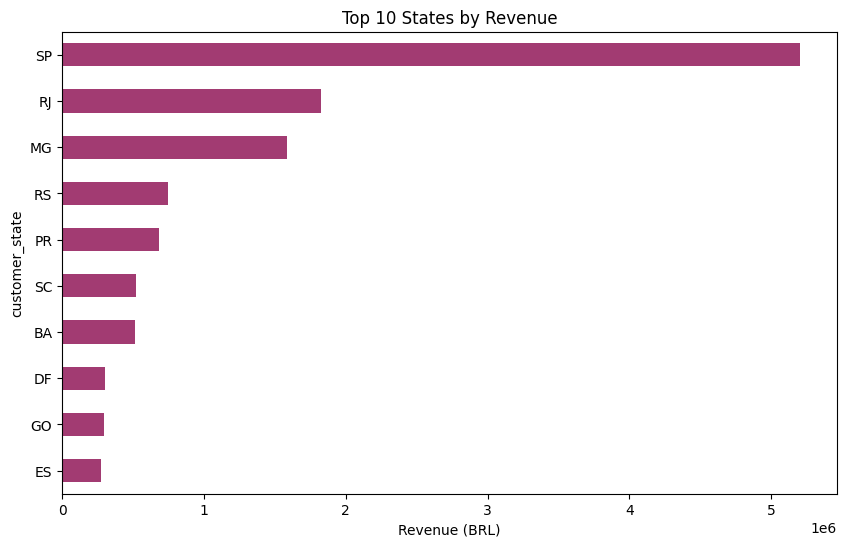

In [6]:
state_orders = full.groupby('customer_state').agg(
    order_count=('order_id', 'nunique'), revenue=('price', 'sum')
).sort_values('revenue', ascending=False).head(10)

plt.figure(figsize=(10, 6))
state_orders['revenue'].sort_values().plot(kind='barh', color='#A23B72')
plt.title('Top 10 States by Revenue'); plt.xlabel('Revenue (BRL)')
plt.show()

## 阶段4.1: RFM客户分层

**注意**: 必须使用 `customer_unique_id`(代表真实用户),而不是 `customer_id`(代表单次下单行为),否则会得出错误的复购率结论。

In [7]:
snapshot_date = full['order_purchase_timestamp'].max() + pd.Timedelta(days=1)
rfm = full.groupby('customer_unique_id').agg(
    recency=('order_purchase_timestamp', lambda x: (snapshot_date - x.max()).days),
    frequency=('order_id', 'nunique'),
    monetary=('price', 'sum')
)
rfm['R_score'] = pd.qcut(rfm['recency'], 5, labels=[5,4,3,2,1]).astype(int)
rfm['M_score'] = pd.qcut(rfm['monetary'].rank(method='first'), 5, labels=[1,2,3,4,5]).astype(int)
rfm['is_repeat'] = rfm['frequency'] > 1

print("复购率:", rfm['is_repeat'].mean().round(4))

复购率: 0.0312


           customer_count  avg_monetary
segment                                
Regular             48199     88.570137
Lost                15791     38.585868
Champions           14992    267.710097
At Risk             14117    277.750972
Loyal                2997    259.867191


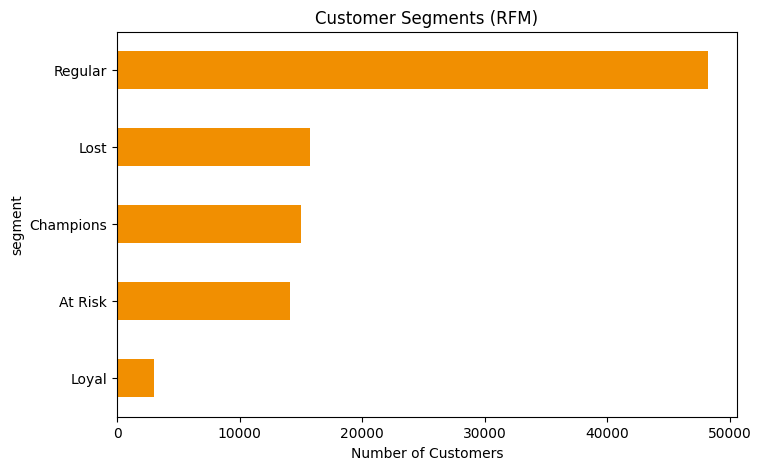

In [8]:
def assign_segment(row):
    if row['is_repeat']:
        return 'Loyal'
    elif row['R_score'] >= 4 and row['M_score'] >= 4:
        return 'Champions'
    elif row['R_score'] <= 2 and row['M_score'] >= 4:
        return 'At Risk'
    elif row['R_score'] <= 2 and row['M_score'] <= 2:
        return 'Lost'
    else:
        return 'Regular'

rfm['segment'] = rfm.apply(assign_segment, axis=1)
segment_summary = rfm.groupby('segment').agg(
    customer_count=('recency', 'count'), avg_monetary=('monetary', 'mean')
).sort_values('customer_count', ascending=False)
print(segment_summary)

plt.figure(figsize=(8, 5))
rfm['segment'].value_counts().sort_values().plot(kind='barh', color='#F18F01')
plt.title('Customer Segments (RFM)'); plt.xlabel('Number of Customers')
plt.show()

## 阶段4.2: 配送时效与客户满意度

                   mean  median  count
review_score                          
1.0           20.849825    16.0   9409
2.0           16.194832    13.0   2941
3.0           13.795278    12.0   7962
4.0           11.848054    10.0  18987
5.0           10.224097     9.0  57060


<Figure size 800x600 with 0 Axes>

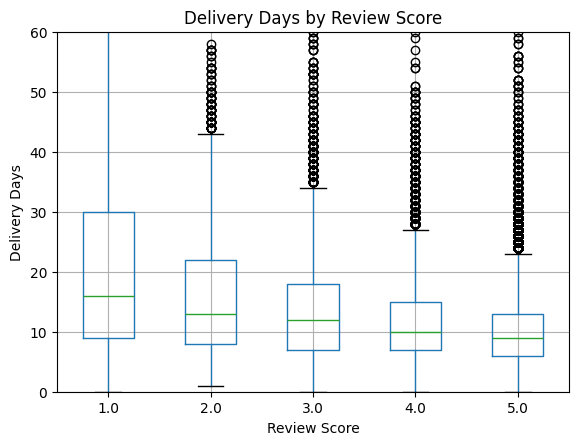

In [9]:
# orders_summary已经包含delivery_days和review_score,直接取用
delivery_review = orders_summary[['order_id', 'delivery_days', 'review_score']].dropna(
    subset=['delivery_days', 'review_score']
)

summary = delivery_review.groupby('review_score')['delivery_days'].agg(['mean', 'median', 'count'])
print(summary)

plt.figure(figsize=(8, 6))
delivery_review.boxplot(column='delivery_days', by='review_score')
plt.ylim(0, 60)
plt.title('Delivery Days by Review Score'); plt.suptitle('')
plt.xlabel('Review Score'); plt.ylabel('Delivery Days')
plt.show()

In [10]:
rho, p_value = stats.spearmanr(delivery_review['delivery_days'], delivery_review['review_score'])
print(f"Spearman rho = {rho:.4f}, p-value = {p_value:.2e}")

Spearman rho = -0.2344, p-value = 0.00e+00


## 结论

详见 `docs/report.md` 完整报告。核心发现: 复购率仅3.12%; At Risk高价值流失客户群是最具召回价值的目标; 配送时长与满意度存在统计显著但强度中等的负相关关系(rho=-0.23, p<0.001)。